# ML-10 — Ranked Refresh Action Playbook

This notebook turns the validation-selected transparent score into a ranked human-review queue. It uses May feature-month evidence and deliberately excludes June outcomes from the exported queue. Actions are suggestions for review—not automated edits—and every row includes reasons plus an evidence-completeness confidence tier.

## 1. Rank the eligible queue

The top 50 represent limited editorial review capacity. Stable sorting makes ties deterministic. The full pseudonymous CSV is ignored by Git; the repository keeps only aggregate action counts and a public-safe chart.

In [1]:
from pathlib import Path
from collections import Counter
import json
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / 'work' / 'scripts').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from work.scripts.refresh_capstone import ALLOWED_ACTIONS, PUBLIC_QUEUE_COLUMNS, assign_action, baseline_score

selection = json.loads((ROOT / 'work' / 'outputs' / 'model_selection.json').read_text(encoding='utf-8'))
assert selection['selected_method'] == 'fixed_baseline'
cache = ROOT / 'work' / 'outputs' / 'model_examples.parquet'
con = duckdb.connect()
may = con.execute("SELECT * FROM read_parquet(?) WHERE month = DATE '2026-05-01'", [str(cache)]).df()
may['baseline_score'] = baseline_score(may)
actions = assign_action(may, may['baseline_score'])
ranked = pd.concat([may.reset_index(drop=True), actions.reset_index(drop=True)], axis=1)
ranked = ranked.sort_values('baseline_score', ascending=False, kind='stable').reset_index(drop=True)
ranked['rank'] = np.arange(1, len(ranked) + 1)
top50 = ranked.head(50).copy()
public_queue = top50[list(PUBLIC_QUEUE_COLUMNS)].copy()
public_queue.to_csv(ROOT / 'work' / 'outputs' / 'final_ranked_queue.csv', index=False)
print(f'Eligible May queue: {len(ranked):,} rows; exported review capacity: {len(public_queue)}')
display(public_queue.head(20))

mkdir -p failed for path C:\Users\hasan\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\hasan\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\hasan\AppData\Local\Temp\matplotlib-5nx67cnw because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Eligible May queue: 93,048 rows; exported review capacity: 50


,rank,content_hash_id,baseline_score,suggested_action,reason_codes,confidence_tier,impressions,impression_momentum,avg_position,position_available,content_age_days
0,1,content_8e1334d6356668e3,89.005243,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,17055,0.133146,10.855350,True,471
1,2,content_17608f489483f8f8,84.529596,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,8127,0.120307,9.489110,True,317
2,3,content_b86db4adb85772b5,84.456464,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,4449,0.142500,10.455383,True,412
3,4,content_9dcaefd5e410fa14,82.558643,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,17520,0.337280,8.728596,True,436
4,5,content_c46df0fa61530d86,82.229047,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,20844,0.366275,8.665323,True,436
5,6,content_8517581218d33225,82.090111,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,5148,0.117130,8.540404,True,317
6,7,content_e7536b365bedaf11,81.970849,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,8986,0.171820,5.496550,True,436
7,8,content_ba3f508f9d3ac24c,81.164633,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,6812,0.286749,9.100411,True,412
8,9,content_a2cf70fc33c61d71,80.720427,refresh_or_expand_review,meaningful_exposure;negative_prior_momentum;vi...,high,5640,0.295939,10.412234,True,412
9,10,content_c7d8ab552944f4f1,80.668849,refresh_or_expand_review,negative_prior_momentum;visible_position,high,1799,0.107692,12.142539,True,412


## 2. Action policy and reason codes

- **Refresh or expand review:** high score plus measured negative prior momentum; inspect intent, accuracy, and coverage gaps.
- **Protect:** strong positive prior momentum; avoid unnecessary disruption and monitor.
- **Consolidate or prune review:** moderate priority with limited exposure; require cannibalization and business-value checks first.
- **Monitor:** missing evidence, low priority, or no sufficiently specific action case.

Confidence depends on rank evidence and measurement completeness, not probability alone.

In [2]:
action_counts = public_queue['suggested_action'].value_counts().to_dict()
confidence_counts = public_queue['confidence_tier'].value_counts().to_dict()
reason_counts = Counter(code for value in public_queue['reason_codes'] for code in value.split(';'))
assert set(action_counts).issubset(ALLOWED_ACTIONS)
assert public_queue['reason_codes'].str.len().gt(0).all()
display(pd.Series(action_counts, name='top_50_rows').rename_axis('suggested_action').to_frame())
display(pd.Series(dict(reason_counts.most_common()), name='top_50_rows').rename_axis('reason_code').to_frame())
display(pd.Series(confidence_counts, name='top_50_rows').rename_axis('confidence').to_frame())

,top_50_rows
suggested_action,
refresh_or_expand_review,50


,top_50_rows
reason_code,
negative_prior_momentum,50
visible_position,50
meaningful_exposure,34


,top_50_rows
confidence,
medium,30
high,20


## 3. Intended use, no-go list, and human review

Use the queue to decide which pages deserve analyst attention first. Before action, verify page intent, seasonality, tracking continuity, legal/business importance, and whether another page serves the same need.

**Do not:** auto-edit or auto-delete; infer Google's algorithm; claim a refresh caused movement; expose client names/domains/URLs/queries; treat missing measurement as zero; or use the score as a performance judgment about a person or client.

In [3]:
prohibited = {'client_hash_id', 'future_decline', 'outcome_impressions', 'outcome_month', 'client_name', 'domain', 'url', 'query', 'title'}
assert prohibited.isdisjoint(public_queue.columns)
assert tuple(public_queue.columns) == PUBLIC_QUEUE_COLUMNS
assert not public_queue['suggested_action'].str.contains('auto', case=False).any()
print('Public-safety assertion passed:', ', '.join(public_queue.columns))
print('Human review is required before every content action.')

Public-safety assertion passed: rank, content_hash_id, baseline_score, suggested_action, reason_codes, confidence_tier, impressions, impression_momentum, avg_position, position_available, content_age_days
Human review is required before every content action.


## 4. Monitoring and retraining triggers

Monitor monthly base rate, top-50 precision after outcomes mature, feature missingness, client coverage, and action mix. Re-audit when the base rate moves by more than 10 percentage points, any key feature's missingness changes by more than 10 points, Precision@50 falls below the current-month base rate, or the data schema/release changes.

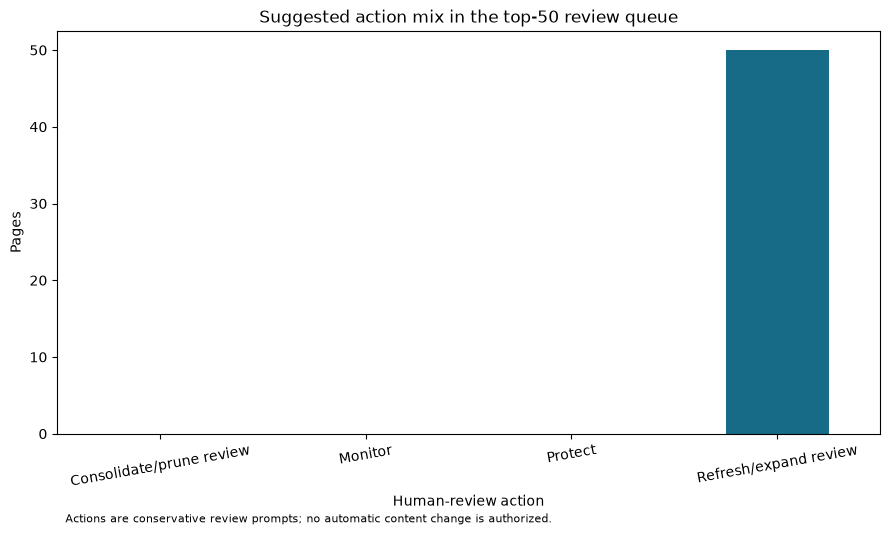

Aggregate action receipt and public-safe chart written.


In [4]:
summary = {
    'ranking_method': 'validation-selected fixed transparent baseline',
    'feature_anchor': '2026-05', 'review_capacity': 50,
    'eligible_rows': int(len(ranked)), 'public_queue_columns': list(PUBLIC_QUEUE_COLUMNS),
    'action_counts': {k: int(v) for k, v in action_counts.items()},
    'reason_counts': {k: int(v) for k, v in reason_counts.items()},
    'confidence_counts': {k: int(v) for k, v in confidence_counts.items()},
    'intended_use': 'prioritize human content review',
    'no_go': ['no automatic edit/delete', 'no causal refresh claim', 'no Google algorithm claim', 'no identifying data exposure', 'no missing-as-zero interpretation'],
    'monitoring_triggers': ['base rate shift over 10 percentage points', 'key-feature missingness shift over 10 points', 'Precision@50 below contemporaneous base rate', 'warehouse schema or release change'],
}
(ROOT / 'work' / 'outputs' / 'action_summary.json').write_text(json.dumps(summary, indent=2) + '\n', encoding='utf-8')
plot_counts = pd.Series(action_counts).reindex(sorted(ALLOWED_ACTIONS), fill_value=0)
plot_counts.index = ['Consolidate/prune review', 'Monitor', 'Protect', 'Refresh/expand review']
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_counts.plot(kind='bar', ax=ax, color='#176B87')
ax.set(title='Suggested action mix in the top-50 review queue', xlabel='Human-review action', ylabel='Pages')
ax.tick_params(axis='x', rotation=10)
ax.text(.01, -.22, 'Actions are conservative review prompts; no automatic content change is authorized.', transform=ax.transAxes, fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / 'work' / 'figures' / 'action_mix.png', dpi=180, bbox_inches='tight')
plt.show()
print('Aggregate action receipt and public-safe chart written.')

## Self-check

- [x] Every row has one allowed action, nonempty reasons, and a confidence tier.
- [x] The queue is deterministic and limited to 50 review candidates.
- [x] Outcome, private, and identifying fields are excluded from the export.
- [x] Intended use, no-go rules, human review, and monitoring triggers are explicit.
- [x] The full pseudonymous queue is ignored; only aggregates are committed.